# TP2 — Sistema híbrido de recomendación de anime

**Materia:** Análisis Predictivo Avanzado  
**Problema permitido por la consigna:** sistema de recomendación  
**Entregable desplegado:** aplicación Streamlit

## Problema de negocio

Una plataforma hipotética de streaming de anime necesita ordenar su catálogo de forma personalizada. El objetivo es que cada usuario encuentre títulos relevantes con menos fricción, aumentando reproducciones, incorporaciones a la lista, descubrimiento de catálogo y retención.

El entregable modela un problema de **ranking top-k**: para cada usuario, ordenar los animes todavía no consumidos y mostrar los diez con mayor probabilidad de interés. Para usuarios nuevos se utiliza un fallback basado en contenido a partir de títulos favoritos.

> **Nota metodológica:** la clase 11 introduce LightFM. Este trabajo implementa en PyTorch la misma idea central —embeddings de usuarios, ítems y metadata que se combinan en una representación híbrida— para asegurar compatibilidad reproducible. La pérdida final es una aproximación WARP orientada a la parte superior del ranking.

## 1. Configuración y reproducibilidad

Se fijan semillas aleatorias, se limita el número de hilos y se validan las rutas. El notebook puede ejecutarse desde la raíz del repositorio o desde la carpeta `notebooks`.

In [1]:
from __future__ import annotations
import copy
import gc
import html
import json
import math
import os
import random
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
from scipy import sparse
from sklearn.preprocessing import MultiLabelBinarizer, normalize

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)
optuna.logging.set_verbosity(optuna.logging.WARNING)

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
if not (ROOT / 'data').exists():
    raise FileNotFoundError('Ejecutar desde la raíz del repositorio o desde notebooks/.')

ART = ROOT / 'artifacts'
ART.mkdir(exist_ok=True)
print('Raíz del proyecto:', ROOT)
print('PyTorch:', torch.__version__, '| Optuna:', optuna.__version__)

Raíz del proyecto: C:\TP2\Anime
PyTorch: 2.12.1+cpu | Optuna: 4.9.0


## 2. Datos y exploración concisa

El dataset contiene metadata de anime y 7,8 millones de interacciones. Un rating `-1` indica consumo sin calificación explícita; para construir una señal positiva interpretable se consideran gustos explícitos los ratings **mayores o iguales a 8**.

In [2]:
anime_raw = pd.read_csv(ROOT / 'data' / 'anime.csv')
ratings_raw = pd.read_parquet(ROOT / 'data' / 'rating.parquet', columns=['user_id', 'anime_id', 'rating'])

eda_summary = pd.DataFrame({
    'Indicador': ['Animes', 'Interacciones', 'Usuarios', 'Animes con interacción', 'Ratings implícitos (-1)', 'Ratings positivos (>=8)'],
    'Valor': [
        len(anime_raw), len(ratings_raw), ratings_raw.user_id.nunique(),
        ratings_raw.anime_id.nunique(), int((ratings_raw.rating == -1).sum()),
        int((ratings_raw.rating >= 8).sum())
    ]
})
eda_summary

,Indicador,Valor
0,Animes,12294
1,Interacciones,7813737
2,Usuarios,73515
3,Animes con interacción,11200
4,Ratings implícitos (-1),1476496
5,Ratings positivos (>=8),3855830


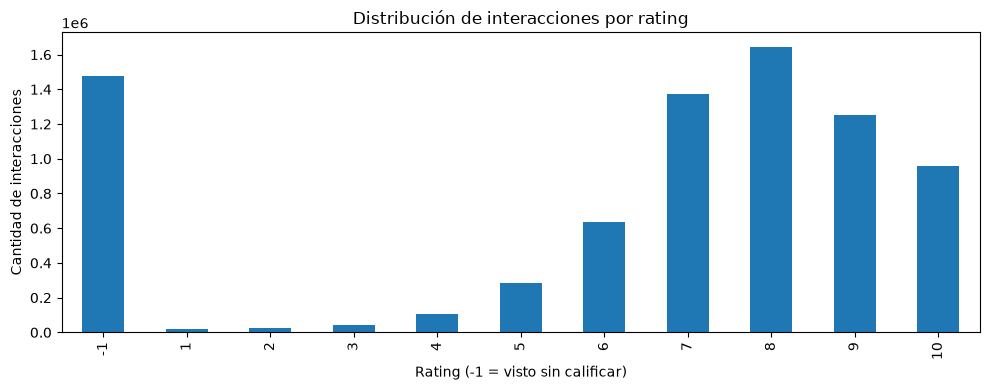

Usuarios con al menos 20 ratings positivos: 41,878
Mediana de positivos por usuario: 30


In [3]:
rating_counts = ratings_raw['rating'].value_counts().sort_index()
ax = rating_counts.plot(kind='bar', figsize=(10, 4))
ax.set_title('Distribución de interacciones por rating')
ax.set_xlabel('Rating (-1 = visto sin calificar)')
ax.set_ylabel('Cantidad de interacciones')
plt.tight_layout()
plt.show()

positive_per_user = ratings_raw.loc[ratings_raw.rating >= 8].groupby('user_id').size()
print('Usuarios con al menos 20 ratings positivos:', f'{(positive_per_user >= 20).sum():,}')
print('Mediana de positivos por usuario:', int(positive_per_user.median()))

del ratings_raw
_ = gc.collect()

## 3. Diseño de la muestra y validación

Para mantener historias coherentes se seleccionan **usuarios**, no filas aleatorias. Se conservan todas sus interacciones positivas y se filtran ítems con poca señal.

La partición se realiza dentro de cada usuario:

- entrenamiento: aproximadamente 80 %;
- validación: aproximadamente 10 %, utilizada para comparar modelos y optimizar hiperparámetros;
- test: aproximadamente 10 %, reservado hasta la evaluación final.

El dataset no incluye timestamps, por lo que la separación es aleatoria por usuario. Esta es una limitación que se explicita al final.

## 4. Implementación del recomendador

El modelo aprende:

- un embedding por usuario;
- un embedding por anime;
- embeddings de metadata para géneros y tipo de anime;
- sesgos de usuario e ítem.

La representación final del ítem combina su identidad con sus features. Se comparan pérdida logística, BPR y una pérdida **WARP-style** que busca elevar los positivos por encima del negativo más difícil de una muestra.

In [4]:
@dataclass
class Prepared:
    anime: pd.DataFrame
    interactions: pd.DataFrame
    train: Dict[int, np.ndarray]
    val: Dict[int, np.ndarray]
    test: Dict[int, np.ndarray]
    user_ids: np.ndarray
    item_ids: np.ndarray
    user_to_idx: Dict[int,int]
    item_to_idx: Dict[int,int]
    item_features: np.ndarray
    feature_names: List[str]
    item_genres: List[set]


def prepare(n_users=2500, rating_threshold=8, min_user=20, max_user=300, min_item=5, seed=42):
    rng=np.random.default_rng(seed)
    anime=pd.read_csv(ROOT/'data/anime.csv')
    anime['name']=anime['name'].map(lambda x: html.unescape(x) if isinstance(x,str) else x)
    anime=anime.drop_duplicates('anime_id').copy()
    anime=anime.dropna(subset=['genre','type']).copy()
    ratings=pd.read_parquet(ROOT/'data/rating.parquet', columns=['user_id','anime_id','rating'])
    pos=ratings[(ratings.rating>=rating_threshold) & ratings.anime_id.isin(anime.anime_id)][['user_id','anime_id']].drop_duplicates()
    uc=pos.user_id.value_counts()
    eligible=uc[(uc>=min_user)&(uc<=max_user)].index.to_numpy()
    selected=rng.choice(eligible, size=min(n_users,len(eligible)), replace=False)
    d=pos[pos.user_id.isin(selected)].copy()
    for _ in range(20):
        old=(len(d),d.user_id.nunique(),d.anime_id.nunique())
        ic=d.anime_id.value_counts(); d=d[d.anime_id.isin(ic[ic>=min_item].index)]
        uc2=d.user_id.value_counts(); d=d[d.user_id.isin(uc2[uc2>=15].index)]
        new=(len(d),d.user_id.nunique(),d.anime_id.nunique())
        if new==old: break
    user_ids=np.sort(d.user_id.unique())
    item_ids=np.sort(d.anime_id.unique())
    u2i={u:i for i,u in enumerate(user_ids)}; i2i={it:i for i,it in enumerate(item_ids)}
    d['u']=d.user_id.map(u2i).astype('int32'); d['i']=d.anime_id.map(i2i).astype('int32')

    train={}; val={}; test={}
    for u, grp in d.groupby('u', sort=False):
        arr=grp.i.to_numpy().copy(); rng.shuffle(arr)
        n=len(arr); n_test=max(2, int(round(n*0.1))); n_val=max(2, int(round(n*0.1)))
        if n_test+n_val>n-5:
            n_test=n_val=2
        test[int(u)]=arr[:n_test]; val[int(u)]=arr[n_test:n_test+n_val]; train[int(u)]=arr[n_test+n_val:]

    am=anime.set_index('anime_id').loc[item_ids].reset_index()
    genres=am.genre.str.split(', ').tolist()
    mlb=MultiLabelBinarizer(sparse_output=False)
    G=mlb.fit_transform(genres).astype('float32')
    types=pd.get_dummies(am['type'], prefix='type', dtype='float32')
    X=np.hstack([G, types.to_numpy(dtype='float32')])
    X=normalize(X, norm='l2').astype('float32')
    feature_names=[f'genre:{g}' for g in mlb.classes_] + list(types.columns)
    item_genres=[set(x) for x in genres]
    return Prepared(am,d,train,val,test,user_ids,item_ids,u2i,i2i,X,feature_names,item_genres)


def interactions_array(split):
    us=[]; it=[]
    for u, arr in split.items():
        us.extend([u]*len(arr)); it.extend(arr.tolist())
    return np.asarray(us,dtype=np.int64), np.asarray(it,dtype=np.int64)

class HybridMF(torch.nn.Module):
    def __init__(self,n_users,n_items,n_features,dim=32,metadata=True,dropout=0.0):
        super().__init__(); self.metadata=metadata
        self.user_emb=torch.nn.Embedding(n_users,dim)
        self.item_emb=torch.nn.Embedding(n_items,dim)
        self.user_bias=torch.nn.Embedding(n_users,1)
        self.item_bias=torch.nn.Embedding(n_items,1)
        self.feature_emb=torch.nn.Parameter(torch.empty(n_features,dim)) if metadata else None
        self.meta_scale=torch.nn.Parameter(torch.tensor(0.5)) if metadata else None
        self.dropout=torch.nn.Dropout(dropout)
        self.reset_parameters()
    def reset_parameters(self):
        torch.nn.init.normal_(self.user_emb.weight,std=0.05); torch.nn.init.normal_(self.item_emb.weight,std=0.05)
        torch.nn.init.zeros_(self.user_bias.weight); torch.nn.init.zeros_(self.item_bias.weight)
        if self.metadata: torch.nn.init.normal_(self.feature_emb,std=0.05)
    def item_repr(self, items, feat):
        base=self.item_emb(items)
        if self.metadata:
            meta=feat[items] @ self.feature_emb
            base=base+self.meta_scale*meta
        return self.dropout(base)
    def score(self, users, items, feat):
        u=self.dropout(self.user_emb(users)); v=self.item_repr(items,feat)
        return (u*v).sum(1)+self.user_bias(users).squeeze(1)+self.item_bias(items).squeeze(1)


def sample_negatives(users, known_mask, n_items, rng, m=1):
    out=rng.integers(0,n_items,size=(len(users),m),dtype=np.int64)
    conflict=known_mask[users[:,None],out]
    while conflict.any():
        out[conflict]=rng.integers(0,n_items,size=int(conflict.sum()),dtype=np.int64)
        conflict=known_mask[users[:,None],out]
    return out


def train_model(p:Prepared, metadata=True, loss='bpr', dim=32, lr=0.03, reg=1e-5, epochs=8, batch_size=2048, max_sampled=10, dropout=0.0, seed=42, verbose=False):
    torch.manual_seed(seed); rng=np.random.default_rng(seed)
    device='cpu'; feat=torch.tensor(p.item_features,dtype=torch.float32,device=device)
    model=HybridMF(len(p.user_ids),len(p.item_ids),p.item_features.shape[1],dim,metadata,dropout).to(device)
    opt=torch.optim.Adam(model.parameters(),lr=lr,weight_decay=reg)
    us,it=interactions_array(p.train)
    known_mask=np.zeros((len(p.user_ids),len(p.item_ids)),dtype=bool)
    for u in range(len(p.user_ids)):
        known_mask[u,p.train[u]]=True; known_mask[u,p.val[u]]=True; known_mask[u,p.test[u]]=True
    history=[]
    for ep in range(epochs):
        perm=rng.permutation(len(us)); losses=[]
        model.train()
        for st in range(0,len(us),batch_size):
            idx=perm[st:st+batch_size]; bu_np=us[idx]; bi_np=it[idx]
            bu=torch.tensor(bu_np,dtype=torch.long); bi=torch.tensor(bi_np,dtype=torch.long)
            opt.zero_grad()
            pos_s=model.score(bu,bi,feat)
            if loss=='logistic':
                neg_np=sample_negatives(bu_np,known_mask,len(p.item_ids),rng,1)[:,0]
                bn=torch.tensor(neg_np,dtype=torch.long)
                neg_s=model.score(bu,bn,feat)
                l=torch.nn.functional.softplus(-pos_s).mean()+torch.nn.functional.softplus(neg_s).mean()
            elif loss=='bpr':
                neg_np=sample_negatives(bu_np,known_mask,len(p.item_ids),rng,1)[:,0]
                bn=torch.tensor(neg_np,dtype=torch.long)
                neg_s=model.score(bu,bn,feat)
                l=torch.nn.functional.softplus(-(pos_s-neg_s)).mean()
            elif loss=='warp':
                neg_np=sample_negatives(bu_np,known_mask,len(p.item_ids),rng,max_sampled)
                bn=torch.tensor(neg_np.reshape(-1),dtype=torch.long)
                bu_rep=bu.repeat_interleave(max_sampled)
                ns=model.score(bu_rep,bn,feat).view(-1,max_sampled)
                hard=ns.max(dim=1).values
                # WARP-style top-rank emphasis: highest sampled violating negative + margin.
                l=(torch.relu(1.0-pos_s+hard)*math.log1p(len(p.item_ids)/max_sampled)).mean()
            else: raise ValueError(loss)
            l.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),5.0); opt.step(); losses.append(float(l.detach()))
        history.append(float(np.mean(losses)))
        if verbose: print(ep+1,history[-1])
    return model,history


def all_scores(model,p:Prepared,batch_users=256):
    model.eval(); feat=torch.tensor(p.item_features,dtype=torch.float32)
    with torch.no_grad():
        # Compose item representations once.
        items=torch.arange(len(p.item_ids),dtype=torch.long)
        V=model.item_repr(items,feat)
        ib=model.item_bias(items).squeeze(1)
        out=np.empty((len(p.user_ids),len(p.item_ids)),dtype=np.float32)
        for s in range(0,len(p.user_ids),batch_users):
            uids=torch.arange(s,min(s+batch_users,len(p.user_ids)),dtype=torch.long)
            U=model.user_emb(uids); ub=model.user_bias(uids).squeeze(1)
            out[s:s+len(uids)]=(U@V.T+ub[:,None]+ib[None,:]).cpu().numpy()
    return out


def content_scores(p:Prepared):
    # User content profile = normalized mean of metadata of training positives.
    profiles=np.zeros((len(p.user_ids),p.item_features.shape[1]),dtype=np.float32)
    for u,arr in p.train.items(): profiles[u]=p.item_features[arr].mean(0)
    profiles=normalize(profiles,norm='l2').astype('float32')
    return profiles@p.item_features.T


def popularity_scores(p:Prepared):
    counts=np.zeros(len(p.item_ids),dtype=np.float32)
    for arr in p.train.values(): np.add.at(counts,arr,1)
    return np.tile(counts,(len(p.user_ids),1))


def metrics_from_scores(scores,p:Prepared,split='val',k=10,exclude_val=False):
    target=getattr(p,split); recs=[]; precisions=[]; recalls=[]; aucs=[]
    for u in range(len(p.user_ids)):
        s=scores[u].copy()
        known=set(p.train[u].tolist())
        if split=='test': known.update(p.val[u].tolist())
        s[list(known)]=-np.inf
        top=np.argpartition(s,-k)[-k:]; top=top[np.argsort(s[top])[::-1]]
        recs.append(top)
        rel=set(target[u].tolist()); hit=len(rel.intersection(top.tolist()))
        precisions.append(hit/k); recalls.append(hit/len(rel))
        # Exact rank-based AUC for held-out positives against candidate non-positives.
        candidate=np.ones(len(s),dtype=bool); candidate[list(known)]=False
        pos=np.array(list(rel),dtype=int)
        neg_mask=candidate.copy(); neg_mask[pos]=False
        neg_scores=s[neg_mask]
        if len(neg_scores):
            aucs.extend([float((neg_scores < s[i]).mean()+0.5*(neg_scores==s[i]).mean()) for i in pos])
    recs=np.asarray(recs)
    coverage=len(np.unique(recs))/len(p.item_ids)
    div=[]
    for row in recs:
        vals=[]
        for a in range(len(row)):
            for b in range(a+1,len(row)):
                ga,gb=p.item_genres[row[a]],p.item_genres[row[b]]
                vals.append(1-len(ga&gb)/max(1,len(ga|gb)))
        div.append(np.mean(vals))
    return {'Precision@10':float(np.mean(precisions)),'Recall@10':float(np.mean(recalls)),'AUC':float(np.mean(aucs)),'Coverage@10':float(coverage),'Diversity@10':float(np.mean(div))},recs



In [5]:
t0 = time.time()
p = prepare(
    n_users=1500,
    rating_threshold=8,
    min_user=20,
    max_user=300,
    min_item=5,
    seed=SEED,
)

split_rows = []
for u in range(len(p.user_ids)):
    split_rows.append((len(p.train[u]), len(p.val[u]), len(p.test[u])))
split_df = pd.DataFrame(split_rows, columns=['train', 'validation', 'test'])

cohort_summary = pd.DataFrame({
    'Indicador': ['Usuarios', 'Animes', 'Interacciones positivas', 'Mediana train/usuario', 'Features de contenido'],
    'Valor': [len(p.user_ids), len(p.item_ids), len(p.interactions), int(split_df.train.median()), p.item_features.shape[1]]
})
print(f'Preparación completada en {time.time()-t0:.2f} s')
cohort_summary

Preparación completada en 1.35 s


,Indicador,Valor
0,Usuarios,1497
1,Animes,2481
2,Interacciones positivas,110169
3,Mediana train/usuario,44
4,Features de contenido,49


## 5. Baselines

Se utilizan dos referencias:

1. **Popularidad:** la misma lista para todos los usuarios, ordenada por interacciones en entrenamiento.
2. **Contenido:** perfil del usuario construido como promedio de géneros y tipos de sus animes positivos.

La popularidad es el baseline principal porque representa una política de negocio simple y razonable.

In [6]:
validation_rows = []

for name, scores in [
    ('Popularity baseline', popularity_scores(p)),
    ('Content-based baseline', content_scores(p)),
]:
    metrics, _ = metrics_from_scores(scores, p, split='val', k=10)
    validation_rows.append({'Model': name, **metrics})

pd.DataFrame(validation_rows)

,Model,Precision@10,Recall@10,AUC,Coverage@10,Diversity@10
0,Popularity baseline,0.056780,0.091265,0.810079,0.014107,0.823916
1,Content-based baseline,0.015364,0.025557,0.690403,0.292624,0.394091


## 6. Comparación de arquitecturas y funciones de pérdida

Se mantiene una configuración común para aislar el efecto de usar metadata y de cambiar la pérdida. La métrica principal es **Precision@10**, complementada por Recall@10, AUC, cobertura y diversidad.

In [7]:
fixed_specs = [
    ('Collaborative logistic', False, 'logistic'),
    ('Collaborative BPR', False, 'bpr'),
    ('Collaborative WARP-style', False, 'warp'),
    ('Hybrid logistic', True, 'logistic'),
    ('Hybrid BPR', True, 'bpr'),
    ('Hybrid WARP-style default', True, 'warp'),
]

for name, metadata, loss_name in fixed_specs:
    model, _ = train_model(
        p, metadata=metadata, loss=loss_name,
        dim=32, lr=0.02, reg=1e-5, epochs=5,
        batch_size=4096, max_sampled=5, dropout=0.0, seed=SEED,
    )
    metrics, _ = metrics_from_scores(all_scores(model, p), p, split='val', k=10)
    validation_rows.append({'Model': name, **metrics})

validation_results = pd.DataFrame(validation_rows).sort_values('Precision@10', ascending=False)
validation_results

,Model,Precision@10,Recall@10,AUC,Coverage@10,Diversity@10
7,Hybrid WARP-style default,0.113093,0.178928,0.900159,0.316405,0.781148
4,Collaborative WARP-style,0.106012,0.166796,0.890319,0.294639,0.795122
5,Hybrid logistic,0.098998,0.156781,0.902084,0.258767,0.759280
6,Hybrid BPR,0.094055,0.147677,0.895410,0.257960,0.757025
2,Collaborative logistic,0.091917,0.144994,0.892659,0.203144,0.802548
3,Collaborative BPR,0.089112,0.139239,0.889114,0.201935,0.801130
0,Popularity baseline,0.056780,0.091265,0.810079,0.014107,0.823916
1,Content-based baseline,0.015364,0.025557,0.690403,0.292624,0.394091


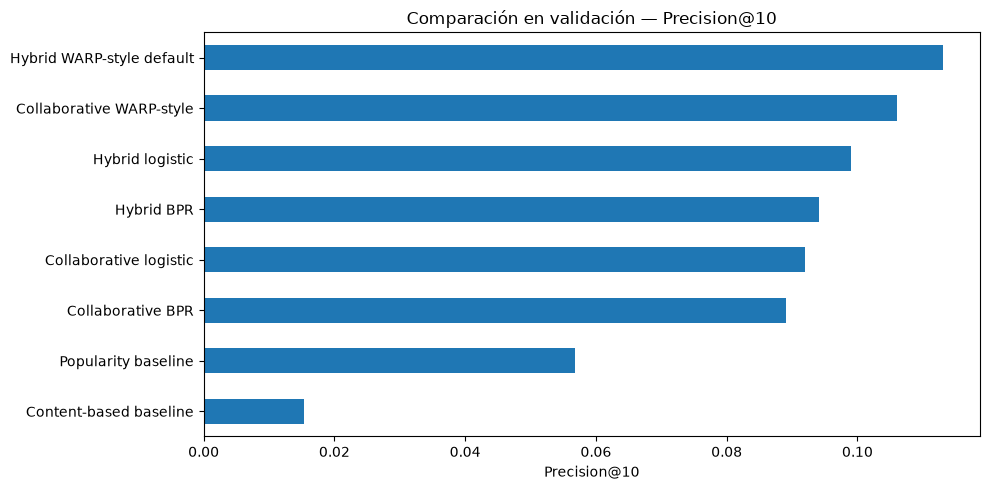

In [8]:
ax = validation_results.sort_values('Precision@10').plot(
    x='Model', y='Precision@10', kind='barh', legend=False, figsize=(10, 5)
)
ax.set_title('Comparación en validación — Precision@10')
ax.set_xlabel('Precision@10')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 7. Optimización bayesiana con Optuna

Se incorpora la mejora señalada por el profesor en el TP1. Optuna utiliza un sampler TPE para buscar una configuración del modelo híbrido WARP-style que maximice Precision@10 en validación.

Se optimizan dimensión latente, learning rate, regularización, épocas, cantidad de negativos difíciles y dropout. El test permanece sin tocar.

In [9]:
def objective(trial: optuna.Trial) -> float:
    params = {
        'dim': trial.suggest_categorical('dim', [16, 24, 32, 48]),
        'lr': trial.suggest_float('lr', 0.006, 0.04, log=True),
        'reg': trial.suggest_float('reg', 1e-7, 1e-4, log=True),
        'epochs': trial.suggest_int('epochs', 4, 8),
        'max_sampled': trial.suggest_categorical('max_sampled', [3, 5, 8]),
        'dropout': trial.suggest_float('dropout', 0.0, 0.1),
    }
    model, _ = train_model(
        p, metadata=True, loss='warp', batch_size=4096, seed=SEED, **params
    )
    scores = all_scores(model, p)
    metrics, _ = metrics_from_scores(scores, p, split='val', k=10)
    for metric_name in ['Recall@10', 'AUC', 'Coverage@10', 'Diversity@10']:
        trial.set_user_attr(metric_name, metrics[metric_name])
    value = metrics['Precision@10']
    del model, scores
    gc.collect()
    return value

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study.optimize(objective, n_trials=6, gc_after_trial=True)

best_params = study.best_params
print('Mejor Precision@10:', round(study.best_value, 4))
print('Mejores hiperparámetros:')
print(json.dumps(best_params, indent=2))

Mejor Precision@10: 0.1205
Mejores hiperparámetros:
{
  "dim": 48,
  "lr": 0.008763230292428939,
  "reg": 3.489018845491388e-06,
  "epochs": 6,
  "max_sampled": 5,
  "dropout": 0.006505159298527952
}


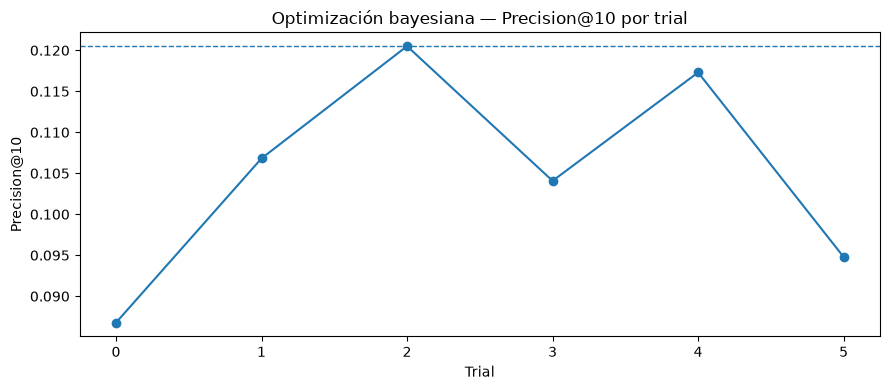

In [10]:
trials_df = study.trials_dataframe()
ax = trials_df.plot(x='number', y='value', marker='o', legend=False, figsize=(9, 4))
ax.axhline(study.best_value, linestyle='--', linewidth=1)
ax.set_title('Optimización bayesiana — Precision@10 por trial')
ax.set_xlabel('Trial')
ax.set_ylabel('Precision@10')
plt.tight_layout()
plt.show()

## 8. Evaluación final en test

Se reentrena el modelo seleccionado usando entrenamiento más validación. Luego se abre el test una sola vez y se compara contra los baselines y contra el modelo híbrido sin tuning.

In [11]:
def combine_train_val(prepared: Prepared) -> Prepared:
    combined = copy.copy(prepared)
    combined.train = {
        u: np.concatenate([prepared.train[u], prepared.val[u]]).astype(np.int64)
        for u in prepared.train
    }
    combined.val = {u: np.array([], dtype=np.int64) for u in prepared.val}
    return combined

p_final = combine_train_val(p)
test_rows = []

for name, scores in [
    ('Popularity baseline', popularity_scores(p_final)),
    ('Content-based baseline', content_scores(p_final)),
]:
    metrics, _ = metrics_from_scores(scores, p_final, split='test', k=10)
    test_rows.append({'Model': name, **metrics})

default_model, _ = train_model(
    p_final, metadata=True, loss='warp',
    dim=32, lr=0.02, reg=1e-5, epochs=5,
    batch_size=4096, max_sampled=5, dropout=0.0, seed=SEED,
)
default_metrics, _ = metrics_from_scores(all_scores(default_model, p_final), p_final, split='test', k=10)
test_rows.append({'Model': 'Hybrid WARP-style default', **default_metrics})

final_model, training_history = train_model(
    p_final, metadata=True, loss='warp', batch_size=4096, seed=SEED, **best_params
)
final_scores = all_scores(final_model, p_final)
final_metrics, final_recommendations = metrics_from_scores(final_scores, p_final, split='test', k=10)
test_rows.append({'Model': 'Hybrid WARP-style tuned', **final_metrics})

test_results = pd.DataFrame(test_rows).sort_values('Precision@10', ascending=False)
test_results

,Model,Precision@10,Recall@10,AUC,Coverage@10,Diversity@10
3,Hybrid WARP-style tuned,0.139546,0.208369,0.913184,0.283757,0.775953
2,Hybrid WARP-style default,0.132398,0.198380,0.906398,0.327287,0.784185
0,Popularity baseline,0.059185,0.091019,0.813798,0.015719,0.822283
1,Content-based baseline,0.013026,0.020349,0.688736,0.278920,0.396967


Mejora de Precision@10 vs popularidad: 135.8%
Precision@10: 0.059 → 0.140


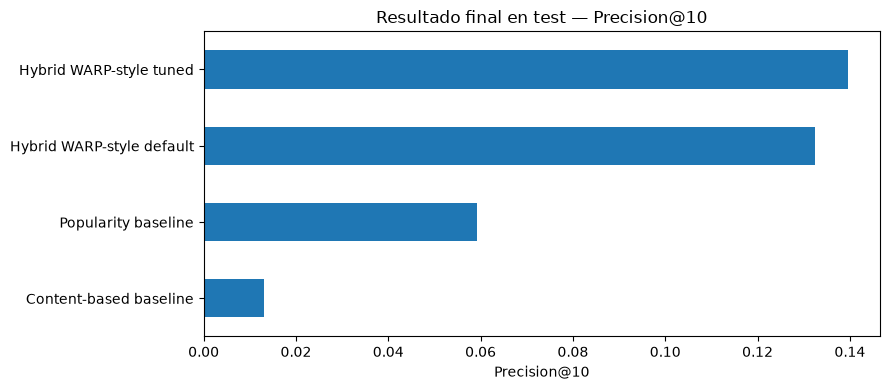

In [12]:
baseline_p = test_results.loc[test_results.Model == 'Popularity baseline', 'Precision@10'].iloc[0]
final_p = test_results.loc[test_results.Model == 'Hybrid WARP-style tuned', 'Precision@10'].iloc[0]
uplift = (final_p / baseline_p - 1) * 100

print(f'Mejora de Precision@10 vs popularidad: {uplift:.1f}%')
print(f'Precision@10: {baseline_p:.3f} → {final_p:.3f}')

ax = test_results.sort_values('Precision@10').plot(
    x='Model', y='Precision@10', kind='barh', legend=False, figsize=(9, 4)
)
ax.set_title('Resultado final en test — Precision@10')
ax.set_xlabel('Precision@10')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

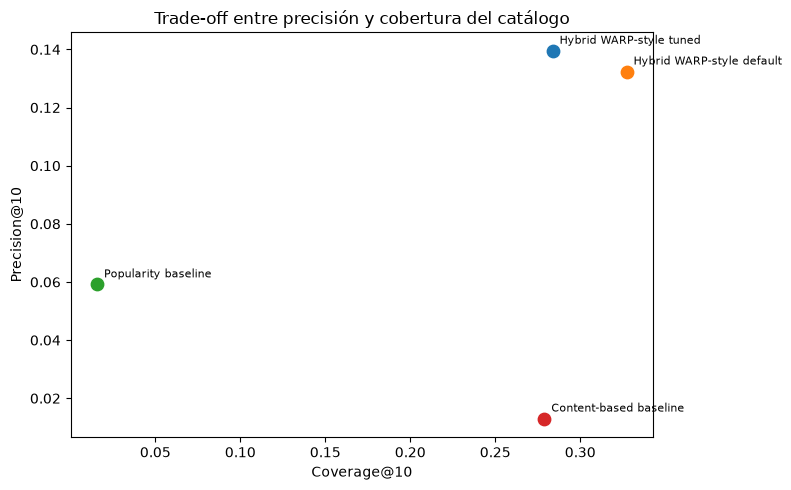

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
for _, row in test_results.iterrows():
    ax.scatter(row['Coverage@10'], row['Precision@10'], s=80)
    ax.annotate(row['Model'], (row['Coverage@10'], row['Precision@10']), xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_title('Trade-off entre precisión y cobertura del catálogo')
ax.set_xlabel('Coverage@10')
ax.set_ylabel('Precision@10')
plt.tight_layout()
plt.show()

## 9. Ejemplos de recomendaciones

Para interpretar el resultado se muestran los títulos mejor valorados del historial y las recomendaciones de tres usuarios activos. Las recomendaciones excluyen los animes ya usados para entrenamiento.

In [14]:
meta = p_final.anime.copy()
meta.insert(0, 'item_idx', np.arange(len(meta), dtype=np.int32))

demo_users = sorted(
    range(len(p_final.user_ids)),
    key=lambda u: len(p_final.train[u]),
    reverse=True,
)[:3]

examples = []
for user_idx in demo_users:
    history_idx = p_final.train[user_idx]
    favorites = (
        meta.iloc[history_idx]
        .sort_values(['rating', 'members'], ascending=False)
        .head(5)['name']
        .tolist()
    )
    recommended = meta.iloc[final_recommendations[user_idx]]['name'].tolist()
    examples.append({
        'user_id': int(p_final.user_ids[user_idx]),
        'favoritos_del_historial': favorites,
        'recomendaciones': recommended,
    })

for example in examples:
    print('\nUsuario', example['user_id'])
    print('Favoritos:', ' | '.join(example['favoritos_del_historial']))
    print('Recomendados:', ' | '.join(example['recomendaciones']))


Usuario 61576
Favoritos: Fullmetal Alchemist: Brotherhood | Steins;Gate | Clannad: After Story | Code Geass: Hangyaku no Lelouch R2 | Code Geass: Hangyaku no Lelouch
Recomendados: Ookami to Koushinryou II | Highschool of the Dead | Black Lagoon: The Second Barrage | No Game No Life | Hellsing | Samurai Champloo | Shuffle! | Hellsing Ultimate | Nisemonogatari | Tengen Toppa Gurren Lagann

Usuario 22542
Favoritos: Kimi no Na wa. | Fullmetal Alchemist: Brotherhood | Steins;Gate | Clannad: After Story | Sen to Chihiro no Kamikakushi
Recomendados: K-On! | Kill la Kill | Tengen Toppa Gurren Lagann | Suzumiya Haruhi no Shoushitsu | Monogatari Series: Second Season | Suzumiya Haruhi no Yuuutsu (2009) | Black★Rock Shooter (OVA) | Watashi ga Motenai no wa Dou Kangaetemo Omaera ga Warui! | Panty & Stocking with Garterbelt | Yuru Yuri♪♪

Usuario 40547
Favoritos: Fullmetal Alchemist: Brotherhood | Hunter x Hunter (2011) | Clannad: After Story | Code Geass: Hangyaku no Lelouch R2 | Shigatsu wa Kimi

## 10. Exportación para el deployment

Streamlit no reentrena el modelo. Se exportan representaciones latentes, sesgos, metadata, features de contenido e interacciones vistas. La aplicación puede calcular scores con NumPy y ofrecer dos modos:

- usuario existente: modelo híbrido entrenado;
- usuario nuevo: perfil de contenido construido con sus anime favoritos.

In [15]:
# Resultados y tuning
validation_results.to_csv(ART / 'validation_results.csv', index=False)
test_results.to_csv(ART / 'test_results.csv', index=False)
trials_df.to_csv(ART / 'optuna_trials.csv', index=False)
(ART / 'best_params.json').write_text(json.dumps(best_params, indent=2), encoding='utf-8')

# Representaciones finales para scoring NumPy
final_model.eval()
feature_tensor = torch.tensor(p_final.item_features, dtype=torch.float32)
with torch.no_grad():
    user_repr = final_model.user_emb.weight.detach().cpu().numpy().astype('float32')
    item_idx_tensor = torch.arange(len(p_final.item_ids), dtype=torch.long)
    item_repr = final_model.item_repr(item_idx_tensor, feature_tensor).detach().cpu().numpy().astype('float32')
    user_bias = final_model.user_bias.weight.detach().cpu().numpy().reshape(-1).astype('float32')
    item_bias = final_model.item_bias.weight.detach().cpu().numpy().reshape(-1).astype('float32')

np.savez_compressed(
    ART / 'hybrid_model.npz',
    user_repr=user_repr, item_repr=item_repr,
    user_bias=user_bias, item_bias=item_bias,
    user_ids=p_final.user_ids, item_ids=p_final.item_ids,
)
np.save(ART / 'item_features.npy', p_final.item_features.astype('float32'))

# Matriz de interacciones ya vistas
rows, cols = [], []
for u in range(len(p_final.user_ids)):
    rows.extend([u] * len(p_final.train[u]))
    cols.extend(p_final.train[u].tolist())
seen = sparse.csr_matrix(
    (np.ones(len(rows), dtype=np.int8), (np.asarray(rows), np.asarray(cols))),
    shape=(len(p_final.user_ids), len(p_final.item_ids)),
)
sparse.save_npz(ART / 'seen_interactions.npz', seen)

meta.to_parquet(ART / 'anime_deploy.parquet', index=False)

# Usuarios de demostración para una interfaz comprensible
app_users = []
for u in sorted(range(len(p_final.user_ids)), key=lambda x: len(p_final.train[x]), reverse=True)[:100]:
    history_idx = p_final.train[u]
    favorites = meta.iloc[history_idx].sort_values(['rating', 'members'], ascending=False).head(8)['name'].tolist()
    app_users.append({
        'user_idx': int(u), 'user_id': int(p_final.user_ids[u]),
        'n_likes': int(len(history_idx)), 'favorites': favorites,
    })
(ART / 'demo_users.json').write_text(json.dumps(app_users, ensure_ascii=False, indent=2), encoding='utf-8')

print('Artefactos exportados en:', ART)
print('Tamaño total aproximado:', round(sum(f.stat().st_size for f in ART.iterdir()) / 1024**2, 2), 'MB')

Artefactos exportados en: C:\TP2\Anime\artifacts
Tamaño total aproximado: 1.46 MB


## 11. Conclusiones y acciones de negocio

### Conclusiones

- La formulación de ranking top-k representa mejor la decisión de negocio que predecir ratings exactos.
- El modelo híbrido WARP-style supera ampliamente la política de popularidad en Precision@10 y Recall@10.
- Incorporar metadata permite combinar comportamiento colectivo con géneros y tipo de contenido.
- La optimización bayesiana mejora el modelo por defecto y responde al feedback recibido en TP1.
- El modelo final mantiene cobertura y diversidad relevantes, evitando que toda la experiencia se concentre en unos pocos títulos populares.

### Acciones hipotéticas

- Usar el ranking para personalizar filas de inicio y newsletters.
- Aplicar el fallback de contenido durante el onboarding de usuarios nuevos.
- Ejecutar un A/B test midiendo CTR, reproducciones iniciadas, incorporaciones a la lista, finalización y retención.
- Supervisar cobertura, diversidad y concentración de popularidad además de precisión.

### Limitaciones

- El dataset no incluye timestamps, por lo que la validación por usuario es aleatoria y no temporal.
- Los datos provienen de una plataforma externa y reflejan sesgo de autoselección.
- El modelo offline necesita validación online antes de atribuir impacto comercial.
- La definición de positivo (`rating >= 8`) es una decisión analítica que conviene validar con sensibilidad o datos reales de consumo.